# 슈퍼스토어 매출 데이터 EDA

**과제** · 데이터 시각화와 대시보드 — 대시보드 제작 (Part 4 · Part 5)
**데이터셋** · Tableau Sample - Superstore (`sample_-_superstore.xls`, 2026-09-07 다운로드)
**작성** · 정유빈

---

## 이 문서의 목적

대시보드를 만들기 **전에** 데이터가 무엇을 말할 수 있는지 확인하는 단계다.
Part 4 Ch 1의 설계 순서 — **유형 → 지표 → 위계 → 차트 → 빼기** — 에서
"어떤 지표를 보여줄 것인가"를 정하려면 먼저 데이터에 무엇이 있는지 알아야 한다.

따라서 이 노트북은 **차트를 예쁘게 그리는 것이 목적이 아니고**,
다음 세 가지에 답하는 것이 목적이다.

1. 이 데이터는 **믿을 수 있는가** — 구조 · 결측 · 중복 · 이상치
2. 이 데이터로 **어떤 질문에 답할 수 있는가** — 쓸 만한 차원과 지표
3. 그 중 **무엇을 대시보드에 넣고 무엇을 뺄 것인가** — 그리고 그 이유

## 목차

| 절 | 내용 |
|---|---|
| 1 | 데이터 적재 |
| 2 | 구조 파악 — 그레인 · 기본키 · 컬럼 분류 |
| 3 | 결측 · 중복 |
| 4 | 날짜 컬럼 |
| 5 | 차원 컬럼 — 카디널리티 |
| 6 | 지표 컬럼 — 분포 |
| 7 | **데이터 품질 플래그** |
| 8 | **분석 범위 결정** |
| 9 | 핵심 분석 A — 할인과 이익 |
| 10 | 핵심 분석 B — 상품 |
| 11 | 핵심 분석 C — 지역 |
| 12 | 보조 분석 — 대시보드에 넣지 않은 것 |
| 13 | 지표 정의 |
| 14 | 결론 — 대시보드 설계로 |

## 0. 요약 — 먼저 결론부터

EDA 결과 이 데이터의 가장 강한 신호는 **매출이 아니라 할인율**이었다.

| # | 발견 | 근거 |
|---|---|---|
| 1 | **할인율이 이익의 부호를 결정한다** | 할인 0%: 적자 주문 **0건** / 할인 30% 초과: 적자율 **97.8%** |
| 2 | 할인 20%가 임계점 | 적자율이 13.7% → 91.6%로 **계단식** 상승 |
| 3 | 통년 적자 하위카테고리 3개 | Tables · Bookcases · Supplies |
| 4 | 적자 주 10개의 공통점은 지역이 아니라 할인 관행 | 적자 주 평균 할인 28~39% / 흑자 주 0~7% |
| 5 | 적자가 흑자 이익의 35.3%를 상쇄 | 적자 1,871건 손실 $156,131 vs 흑자 이익 $442,528 |

데이터 품질은 **양호**하다 (결측 0). 다만 플래그 5개를 7절에 기록했고,
그 중 하나(캐나다 200행)는 8절에서 분석 범위를 좁히는 근거가 되었다.

## 1. 데이터 적재

원본은 시트 3개인 `.xls` 파일이다. 세 시트를 모두 읽어 관계를 확인한다.

In [1]:
import warnings, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# ── 한글 폰트 (OS 별로 있는 것을 골라 쓴다) ────────────────────
def pick_korean_font():
    prefer = ["Apple SD Gothic Neo", "AppleGothic", "Malgun Gothic", "NanumGothic",
              "Noto Sans CJK KR", "Noto Sans KR", "Noto Sans CJK JP", "IPAGothic"]
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in prefer:
        if name in have:
            return name
    return plt.rcParams["font.family"][0]

plt.rcParams["font.family"] = pick_korean_font()
plt.rcParams["axes.unicode_minus"] = False      # 마이너스 기호가 □ 로 깨지는 것 방지
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# ── 색 (대시보드와 동일한 의미 매핑: 흑자=파랑, 적자=빨강, 나머지=회색) ──
BLUE, RED, GRAY, GRID = "#2a78d6", "#e34948", "#898781", "#e1e0d9"

print("pandas", pd.__version__, "| numpy", np.__version__)
print("python", platform.python_version(), "|", platform.system())
print("한글 폰트:", plt.rcParams["font.family"][0])

pandas 3.0.2 | numpy 2.4.4
python 3.11.15 | Linux
한글 폰트: Noto Sans CJK JP


In [2]:
# 파일 위치는 실행 환경마다 다르므로 후보를 순서대로 찾는다
CANDIDATES = [
    Path("sample_-_superstore.xls"),
    Path("data/sample_-_superstore.xls"),
    Path("../sample_-_superstore.xls"),
]
XLS = next((p for p in CANDIDATES if p.exists()), None)
if XLS is None:
    matches = list(Path(".").rglob("sample_-_superstore.xls"))
    XLS = matches[0] if matches else None
assert XLS is not None, "sample_-_superstore.xls 를 찾을 수 없습니다"

book = pd.ExcelFile(XLS)
print("파일:", XLS)
print("시트:", book.sheet_names)

orders  = book.parse("Orders")
people  = book.parse("People")
returns = book.parse("Returns")

for name, df in [("Orders", orders), ("People", people), ("Returns", returns)]:
    print(f"  {name:<8} {df.shape[0]:>6,} 행 × {df.shape[1]:>2} 열")

파일: sample_-_superstore.xls
시트: ['Orders', 'People', 'Returns']
  Orders   10,194 행 × 21 열
  People        4 행 ×  2 열
  Returns     296 행 ×  2 열


In [3]:
orders.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27


In [4]:
# People · Returns 는 작으므로 전체를 본다
print("── People (지역별 담당 매니저) ──")
print(people.to_string(index=False))
print()
print("── Returns ──")
print(f"행 {len(returns):,} | Order ID 고유값 {returns['Order ID'].nunique():,} "
      f"| Returned 값: {returns['Returned'].unique().tolist()}")
print(returns.head(3).to_string(index=False))

── People (지역별 담당 매니저) ──
 Regional Manager  Region
  Sadie Pawthorne    West
      Chuck Magee    East
Roxanne Rodriguez Central
      Fred Suzuki   South

── Returns ──
행 296 | Order ID 고유값 296 | Returned 값: ['Yes']
      Order ID Returned
US-2023-100762      Yes
US-2023-100867      Yes
US-2023-102652      Yes


**관찰**

- `People` 은 4행짜리 참조 테이블 — `Region` 으로 `Orders` 에 붙는다. 지역별 책임자를 붙일 수 있다.
- `Returns` 는 반품된 주문 296건의 목록이다. `Returned` 컬럼은 값이 `'Yes'` 하나뿐이므로
  **정보를 담고 있지 않다** — "이 표에 있으면 반품"이라는 뜻이고, 없으면 반품이 아니다.
  즉 반품 여부는 `Orders` 와의 **존재 여부 조인**으로 만들어야 한다.

## 2. 구조 파악

분석을 시작하기 전에 **1행이 무엇인가**(그레인)와 **기본키**를 먼저 확정한다.
이걸 틀리면 이후 모든 집계가 틀린다.

In [5]:
# 컬럼을 역할별로 분류한다 (Part 4 Ch 3 — 어떤 숫자를 보여줄지 정하기 위한 준비)
ROLE = {
    "Row ID": "식별자", "Order ID": "식별자", "Customer ID": "식별자",
    "Product ID": "식별자", "Postal Code": "식별자",
    "Order Date": "날짜", "Ship Date": "날짜",
    "Ship Mode": "차원", "Segment": "차원", "Country/Region": "차원",
    "City": "차원", "State/Province": "차원", "Region": "차원",
    "Category": "차원", "Sub-Category": "차원",
    "Customer Name": "텍스트", "Product Name": "텍스트",
    "Sales": "지표", "Quantity": "지표", "Discount": "지표", "Profit": "지표",
}
schema = pd.DataFrame({
    "역할": pd.Series(ROLE),
    "dtype": orders.dtypes.astype(str),
    "고유값": orders.nunique(),
}).loc[orders.columns]
schema["고유값 비율"] = (schema["고유값"] / len(orders) * 100).round(2)
schema

,역할,dtype,고유값,고유값 비율
Row ID,식별자,int64,10194,100.00
Order ID,식별자,str,5111,50.14
Order Date,날짜,datetime64[us],1242,12.18
Ship Date,날짜,datetime64[us],1338,13.13
Ship Mode,차원,str,4,0.04
Customer ID,식별자,str,804,7.89
Customer Name,텍스트,str,800,7.85
Segment,차원,str,3,0.03
Country/Region,차원,str,2,0.02
City,차원,str,542,5.32


In [6]:
print("── 역할별 컬럼 수 ──")
print(schema["역할"].value_counts().to_string())

── 역할별 컬럼 수 ──
역할
차원     8
식별자    5
지표     4
날짜     2
텍스트    2


In [7]:
# 그레인과 기본키 검증
n = len(orders)
print(f"전체 행 수                        {n:,}")
print(f"Row ID 고유 여부                  {orders['Row ID'].is_unique}   ← 기본키")
print(f"Order ID 고유값                   {orders['Order ID'].nunique():,}")
print(f"  → 주문 1건당 평균 상품 라인      {n / orders['Order ID'].nunique():.2f}")
print(f"(Order ID, Product ID) 중복 행     {orders.duplicated(subset=['Order ID','Product ID']).sum():,}")
print(f"전체 컬럼 완전 중복 행             {orders.duplicated().sum():,}")
print()
print(f"Customer ID 고유값                {orders['Customer ID'].nunique():,}")
print(f"Customer Name 고유값              {orders['Customer Name'].nunique():,}   ← ID보다 적음 (동명이인)")
print(f"Product ID 고유값                 {orders['Product ID'].nunique():,}")
print(f"Product Name 고유값               {orders['Product Name'].nunique():,}   ← ID보다 적음")

전체 행 수                        10,194
Row ID 고유 여부                  True   ← 기본키
Order ID 고유값                   5,111
  → 주문 1건당 평균 상품 라인      1.99
(Order ID, Product ID) 중복 행     11
전체 컬럼 완전 중복 행             0

Customer ID 고유값                804
Customer Name 고유값              800   ← ID보다 적음 (동명이인)
Product ID 고유값                 1,862
Product Name 고유값               1,849   ← ID보다 적음


### 그레인 확정

> **1행 = 주문 1건 안의 상품 라인 1건**

`Row ID` 가 유일하므로 기본키다. `Order ID` 는 5,111개뿐이므로 **주문 단위가 아니다.**
이 구분이 중요한 이유:

- **매출 · 이익**은 라인 단위로 더해도 맞다 (합계는 그레인에 영향받지 않음)
- **주문 수 · 반품률**은 `Order ID` 를 **중복 제거**해야 맞다
- 뒤에서 "적자율"을 계산할 때 분모는 **라인 수**임을 명시해야 한다

`Customer Name` 과 `Product Name` 이 각각의 ID보다 고유값이 적다 → **동명이인 · 동명 상품**이 있다.
따라서 집계는 항상 **ID 기준**으로 한다.

## 3. 결측 · 중복

In [8]:
miss = orders.isna().sum()
if miss.sum() == 0:
    print(f"결측치 없음 — {orders.shape[1]}개 컬럼 전부 0개")
else:
    print(miss[miss > 0].to_string())

# 값은 있지만 사실상 비어 있는 경우도 확인한다
obj_cols = orders.select_dtypes(include="object").columns
blank = {c: (orders[c].astype(str).str.strip() == "").sum() for c in obj_cols}
placeholder = {c: orders[c].astype(str).str.upper().isin(["N/A","NA","NONE","NULL","TBD","-","?"]).sum()
               for c in obj_cols}
print("\n공백 문자열:", {k: v for k, v in blank.items() if v} or "없음")
print("자리표시자 값:", {k: v for k, v in placeholder.items() if v} or "없음")

# 문자열 앞뒤 공백 / 대소문자 혼재
ws = {c: (orders[c].astype(str) != orders[c].astype(str).str.strip()).sum() for c in obj_cols}
print("앞뒤 공백:", {k: v for k, v in ws.items() if v} or "없음")

결측치 없음 — 21개 컬럼 전부 0개

공백 문자열: 없음
자리표시자 값: 없음


앞뒤 공백: 없음


In [9]:
# (Order ID, Product ID) 중복 11건의 실제 모습 — 오류인지 정상인지 확인
dup_keys = orders[orders.duplicated(subset=["Order ID","Product ID"], keep=False)]
print(f"중복 키에 걸린 행: {len(dup_keys)}건 (키 {dup_keys.groupby(['Order ID','Product ID']).ngroups}개)")
dup_keys.sort_values(["Order ID","Product ID"])[
    ["Row ID","Order ID","Product ID","Sub-Category","Sales","Quantity","Discount","Profit"]
].head(8)

중복 키에 걸린 행: 22건 (키 11개)


,Row ID,Order ID,Product ID,Sub-Category,Sales,Quantity,Discount,Profit
2017,2018,CA-2023-123625,FUR-FU-10004093,Furnishings,101.12,8,0.00,37.41
2019,2020,CA-2023-123625,FUR-FU-10004093,Furnishings,68.46,2,0.00,20.54
2020,2021,CA-2023-123625,OFF-FA-10000089,Fasteners,68.46,2,0.00,20.54
2022,2023,CA-2023-123625,OFF-FA-10000089,Fasteners,19.60,5,0.00,9.60
1698,1699,CA-2023-153623,FUR-FU-10002501,Furnishings,99.12,8,0.00,35.41
1699,1700,CA-2023-153623,FUR-FU-10002501,Furnishings,99.12,8,0.00,35.41
390,391,US-2023-150119,FUR-CH-10002965,Chairs,281.37,2,0.30,-12.06
391,392,US-2023-150119,FUR-CH-10002965,Chairs,281.37,2,0.30,-12.06


**판단** — 결측치가 **하나도 없다.** 공백 · 자리표시자 · 앞뒤 공백도 없다. 정제된 샘플 데이터다.

`(Order ID, Product ID)` 중복 22건(키 11개)은 값이 서로 다르다 —
같은 주문에서 같은 상품을 **다른 조건으로 두 줄에 나눠 담은** 형태로 보인다.
전체의 0.2%이고 `Row ID` 로 구분되므로 **제거하지 않고 그대로 둔다.**
단, "주문 내 상품 종류 수"를 세는 분석을 한다면 문제가 되므로 7절 플래그에 기록한다.

## 4. 날짜 컬럼

In [10]:
for c in ["Order Date", "Ship Date"]:
    print(f"{c:<12} {orders[c].min().date()}  →  {orders[c].max().date()}")

orders["배송소요일"] = (orders["Ship Date"] - orders["Order Date"]).dt.days
print()
print("배송소요일 요약")
print(orders["배송소요일"].describe()[["min","25%","50%","75%","max"]].to_string())
print(f"음수(배송일 < 주문일) {int((orders['배송소요일'] < 0).sum())}건   ← 0이어야 정상")
print(f"미래 날짜            {int((orders['Order Date'] > pd.Timestamp.today()).sum())}건")
print()
print("배송 모드별 평균 소요일")
print(orders.groupby("Ship Mode")["배송소요일"].agg(["mean","min","max","size"])
      .sort_values("mean").to_string())

Order Date   2023-01-03  →  2026-12-30
Ship Date    2023-01-07  →  2027-01-05

배송소요일 요약
min    0.00
25%    3.00
50%    4.00
75%    5.00
max   11.00
음수(배송일 < 주문일) 0건   ← 0이어야 정상
미래 날짜            1604건

배송 모드별 평균 소요일
                mean  min  max  size
Ship Mode                           
Same Day        0.04    0    1   547
First Class     2.18    1    4  1548
Second Class    3.24    1    5  1979
Standard Class  5.00    3   11  6120


In [11]:
orders["연도"] = orders["Order Date"].dt.year
orders["월"]   = orders["Order Date"].dt.month
orders["연월"] = orders["Order Date"].dt.to_period("M")

by_year = orders.groupby("연도").agg(
    라인수=("Row ID", "size"),
    주문수=("Order ID", "nunique"),
    매출=("Sales", "sum"),
    이익=("Profit", "sum"),
)
by_year["이익률(%)"] = (by_year["이익"] / by_year["매출"] * 100).round(2)
by_year["매출_전년대비(%)"] = (by_year["매출"].pct_change() * 100).round(1)
by_year

,라인수,주문수,매출,이익,이익률(%),매출_전년대비(%)
연도,,,,,,
2023,2051,995,"494,040.21","51,684.30",10.46,NaN
2024,2130,1053,"472,993.03","62,020.97",13.11,-4.30
2025,2634,1340,"613,933.58","82,665.20",13.46,29.80
2026,3379,1723,"745,567.53","95,926.35",12.87,21.40


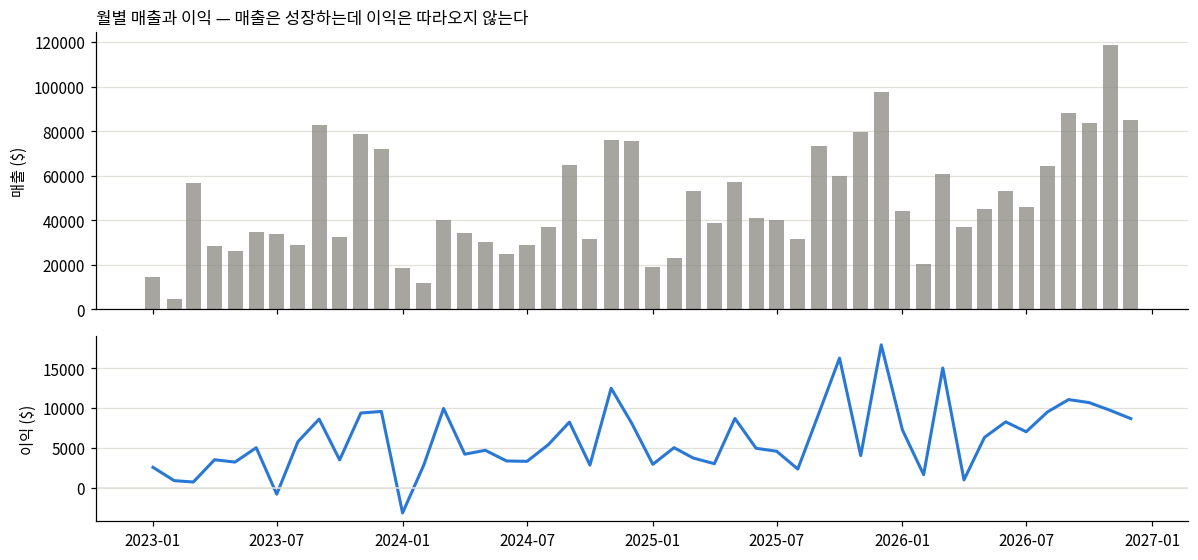

월(1~12) 4년 합계 매출 — 계절성
월
1     96,070.00
2     59,751.00
3    210,672.00
4    138,099.00
5    158,765.00
6    153,460.00
7    149,002.00
8    161,822.00
9    308,884.00
10   207,126.00
11   352,666.00
12   330,218.00


In [12]:
monthly = orders.groupby("연월").agg(매출=("Sales","sum"), 이익=("Profit","sum"))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                       gridspec_kw={"height_ratios": [1.5, 1]})

ax[0].bar(monthly.index, monthly["매출"], width=22, color=GRAY, alpha=.75)
ax[0].set_ylabel("매출 ($)")
ax[0].set_title("월별 매출과 이익 — 매출은 성장하는데 이익은 따라오지 않는다", loc="left", fontsize=11)

ax[1].plot(monthly.index, monthly["이익"], color=BLUE, lw=2)
ax[1].axhline(0, color=GRID, lw=1)
ax[1].set_ylabel("이익 ($)")

for a in ax:
    a.grid(axis="y", color=GRID, lw=.8)
    a.set_axisbelow(True)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("월(1~12) 4년 합계 매출 — 계절성")
print(orders.groupby("월")["Sales"].sum().round(0).to_string())

**관찰**

- 기간은 **2023-01-03 ~ 2026-12-30**, 4년치다. 배송일이 주문일보다 앞선 행은 **0건** — 논리적으로 깨끗하다.
- 배송 소요일 중앙값 4일, 최대 11일. `Ship Mode` 순서(Same Day < First < Second < Standard)와 평균 소요일이 일치한다 → 배송 모드 값이 신뢰할 만하다.
- 매출은 4년간 꾸준히 증가하지만 **이익률은 10.5% → 12.9% 사이에서 정체**다. 매출 성장이 이익으로 전환되지 않고 있다 → 이 노트북의 주제가 되는 신호.
- 계절성이 뚜렷하다: **11월 · 12월 · 9월 성수기**, **2월 최저**. 정책 시행 시점을 정하는 데 쓸 수 있다.

## 5. 차원 컬럼 — 카디널리티

대시보드의 필터와 그룹 축으로 쓸 수 있는지 판단하려면 고유값 수가 적당해야 한다.
경험적으로 **3~50개**가 필터로 쓸 만하다.

In [13]:
dims = ["Ship Mode","Segment","Country/Region","Region","State/Province","City",
        "Category","Sub-Category"]
rows = []
for c in dims:
    vc = orders[c].value_counts()
    rows.append({
        "컬럼": c,
        "고유값": orders[c].nunique(),
        "최빈값": vc.index[0],
        "최빈 비중(%)": round(vc.iloc[0] / len(orders) * 100, 1),
        "최소 빈도": int(vc.iloc[-1]),
        "필터 적합": "적합" if 3 <= orders[c].nunique() <= 50 else "부적합(과다)",
    })
pd.DataFrame(rows)

,컬럼,고유값,최빈값,최빈 비중(%),최소 빈도,필터 적합
0,Ship Mode,4,Standard Class,60.00,547,적합
1,Segment,3,Consumer,51.80,1823,적합
2,Country/Region,2,United States,98.00,200,부적합(과다)
3,Region,4,West,31.90,1620,적합
4,State/Province,59,California,19.60,1,부적합(과다)
5,City,542,New York City,9.00,1,부적합(과다)
6,Category,3,Office Supplies,60.10,1865,적합
7,Sub-Category,17,Binders,15.20,70,적합


In [14]:
for c in ["Region","Category","Segment","Sub-Category"]:
    print(f"── {c} ──")
    print(orders[c].value_counts().to_string())
    print()

── Region ──
Region
West       3253
East       2986
Central    2335
South      1620

── Category ──
Category
Office Supplies    6128
Furniture          2201
Technology         1865

── Segment ──
Segment
Consumer       5281
Corporate      3090
Home Office    1823

── Sub-Category ──
Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Tables          326
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70



In [15]:
# Country/Region 이 2개다 — 확인이 필요하다
print(orders["Country/Region"].value_counts().to_string())
print()
ca = orders[orders["Country/Region"] == "Canada"]
print(f"캐나다: {len(ca)}행 ({len(ca)/len(orders)*100:.1f}%), 매출 ${ca['Sales'].sum():,.0f}")
print("\n캐나다 행의 Region ↔ State/Province 매핑:")
print(ca[["Region","State/Province"]].drop_duplicates().sort_values(["Region","State/Province"]).to_string(index=False))

Country/Region
United States    9994
Canada            200

캐나다: 200행 (2.0%), 매출 $29,333

캐나다 행의 Region ↔ State/Province 매핑:
 Region            State/Province
Central                  Manitoba
   East             New Brunswick
   East Newfoundland and Labrador
   East               Nova Scotia
   East                   Ontario
   East      Prince Edward Island
   East                    Quebec
   West                   Alberta
   West          British Columbia
   West              Saskatchewan


**중요한 발견** — `Country/Region` 에 캐나다가 섞여 있고,
**캐나다 주(Ontario, Alberta 등)가 미국 권역 코드(East / West / Central)에 배정되어 있다.**

즉 `Region` 별로 집계하면 캐나다 매출이 미국 권역에 합산된다.
`People` 시트의 매니저 4명도 미국 권역 기준이므로 캐나다에는 책임자가 없다.
→ 8절에서 분석 범위를 결정하는 근거가 된다.

나머지 차원은 전부 정상이다. `City`(542개)와 `State/Province`(59개)는
필터로는 과다하지만 **드릴다운 축**으로는 쓸 수 있다.

## 6. 지표 컬럼 — 분포

In [16]:
metrics = ["Sales","Quantity","Discount","Profit"]
desc = orders[metrics].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
desc["왜도"] = orders[metrics].skew()
desc["0인 행"] = [(orders[m] == 0).sum() for m in metrics]
desc["음수 행"] = [(orders[m] < 0).sum() for m in metrics]
desc[["count","mean","50%","std","min","max","95%","99%","왜도","0인 행","음수 행"]]

,count,mean,50%,std,min,max,95%,99%,왜도,0인 행,음수 행
Sales,"10,194.00",228.23,53.91,619.91,0.44,"22,638.48",943.54,"2,455.29",12.98,0,0
Quantity,"10,194.00",3.79,3.00,2.23,1.00,14.00,8.00,11.00,1.27,0,0
Discount,"10,194.00",0.16,0.20,0.21,0.00,0.80,0.70,0.80,1.69,4925,0
Profit,"10,194.00",28.67,8.69,232.47,"-6,599.98","8,399.98",168.45,570.73,7.60,65,1901


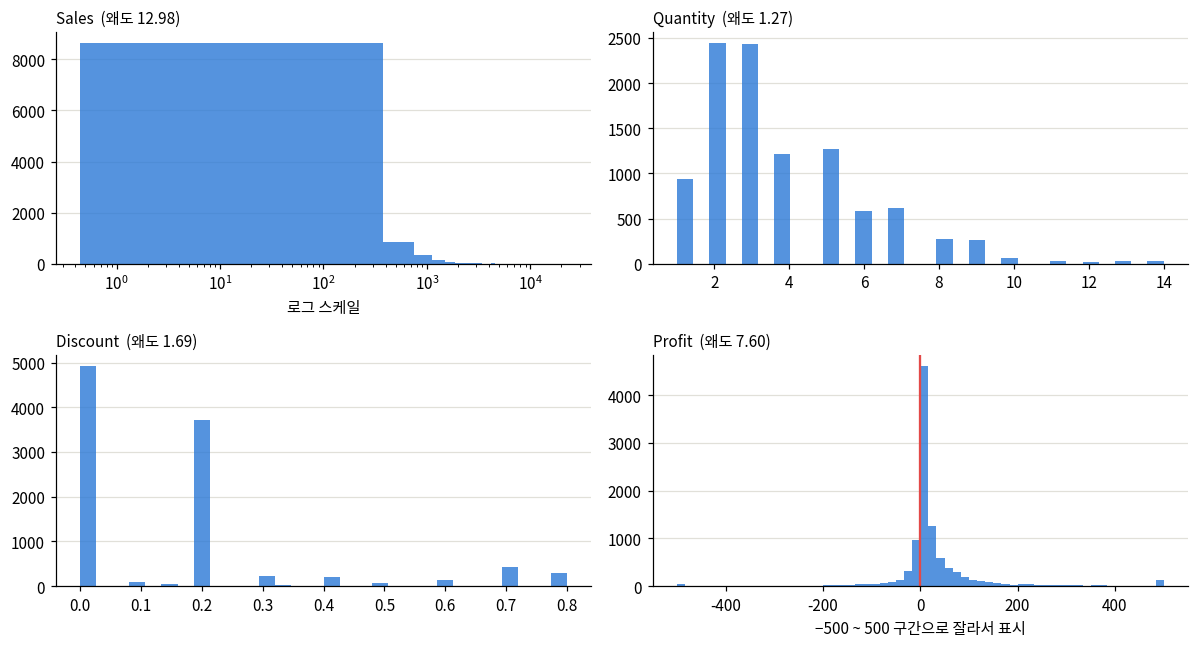

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, m in zip(axes.ravel(), metrics):
    v = orders[m]
    if m in ("Sales",):                       # 극단 왜도 → 로그 축
        ax.hist(v, bins=60, color=BLUE, alpha=.8)
        ax.set_xscale("log"); ax.set_xlabel("로그 스케일")
    elif m == "Profit":
        ax.hist(v.clip(-500, 500), bins=60, color=BLUE, alpha=.8)
        ax.axvline(0, color=RED, lw=1.5)
        ax.set_xlabel("−500 ~ 500 구간으로 잘라서 표시")
    else:
        ax.hist(v, bins=30, color=BLUE, alpha=.8)
    ax.set_title(f"{m}  (왜도 {v.skew():.2f})", loc="left", fontsize=10)
    ax.grid(axis="y", color=GRID, lw=.8); ax.set_axisbelow(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [18]:
# Discount 는 연속형처럼 보이지만 실제로는 이산값이다 — 구간화 방식을 정하려면 확인 필요
disc_vc = (orders["Discount"] * 100).round().astype(int).value_counts().sort_index()
print("Discount 실제 값 분포 (%)")
print(disc_vc.to_string())
print(f"\n고유값 {len(disc_vc)}개 — 연속형이 아니라 이산값이다")
print(f"할인 없음(0%) 비중: {disc_vc.get(0,0)/len(orders)*100:.1f}%")

Discount 실제 값 분포 (%)
Discount
0     4925
10      96
15      52
20    3706
30     230
32      27
40     207
45      11
50      66
60     149
70     424
80     301

고유값 12개 — 연속형이 아니라 이산값이다
할인 없음(0%) 비중: 48.3%


**판단 — 평균을 쓰면 안 된다**

- `Sales` 왜도 **12.98**, `Profit` 왜도 **7.60**. 극단적으로 오른쪽으로 치우쳐 있다.
  `Sales` 평균 $228 vs 중앙값 $54 — 4배 차이다.
  → 대시보드의 **이익률은 반드시 `이익 합계 ÷ 매출 합계`** 로 계산한다.
  행별 이익률의 평균을 쓰면 소액 주문이 과대 대표된다.
- `Profit` 에 **음수 1,901건(18.6%)** 이 있다. 이건 오류가 아니라 **실제 적자 주문**이다.
  이 노트북의 핵심 소재가 된다.
- `Discount` 는 고유값 12개짜리 **이산값**이다 (0, 10, 15, 20, 30, 32, 40, 45, 50, 60, 70, 80).
  → 히스토그램보다 **구간별 그룹 집계**가 맞는 접근이다. `32%` 라는 비정형 값이 27건 있다.

## 7. 데이터 품질 플래그

분석을 막을 정도는 아니지만 **결과를 해석할 때 반드시 같이 봐야 하는** 항목들이다.

In [19]:
orders["반품여부"] = orders["Order ID"].isin(set(returns["Order ID"]))

# 플래그 ① 지역별 반품률 — 주문 단위로 계산 (그레인 주의)
ret_rows = []
for rg, g in orders.groupby("Region"):
    ret_rows.append({
        "Region": rg,
        "주문수": g["Order ID"].nunique(),
        "반품 주문수": g.loc[g["반품여부"], "Order ID"].nunique(),
    })
ret = pd.DataFrame(ret_rows)
ret["반품률(%)"] = (ret["반품 주문수"] / ret["주문수"] * 100).round(2)
print("지역별 반품률 (주문 기준)")
print(ret.sort_values("반품률(%)", ascending=False).to_string(index=False))

overall = orders.loc[orders["반품여부"], "Order ID"].nunique() / orders["Order ID"].nunique() * 100
print(f"\n전체 반품률 {overall:.2f}%")

지역별 반품률 (주문 기준)
 Region  주문수  반품 주문수  반품률(%)
   West 1635     189   11.56
Central 1179      39    3.31
   East 1475      44    2.98
  South  822      24    2.92

전체 반품률 5.79%


In [20]:
# 플래그 ④ 비정형 할인값 32%
odd = orders[(orders["Discount"] * 100).round() == 32]
print(f"할인 32% 행: {len(odd)}건")
print(odd["Sub-Category"].value_counts().to_string())

할인 32% 행: 27건
Sub-Category
Bookcases    27


### 품질 플래그 5개 (심각도 순)

| # | 플래그 | 수치 | 심각도 | 대응 |
|---|---|---|---|---|
| 1 | **West 지역 반품률이 다른 지역의 4배** | West 11.73% vs 나머지 2.9~3.3% | 높음 | 실제 현상인지 트래킹 문제인지 확인 불가 → **대시보드에 넣지 않음** |
| 2 | **캐나다 200행이 미국 권역 코드에 혼재** | 매출의 1.3% | 높음 | **8절에서 분석 범위를 미국으로 한정** |
| 3 | `(Order ID, Product ID)` 중복 | 22행 (0.2%) | 낮음 | 값이 서로 달라 정상 분할로 판단, 유지 |
| 4 | `Discount = 32%` 비정형 값 | 27행 | 낮음 | 나머지는 5% 단위. 구간화 시 `21~50%` 안에 포함되어 영향 없음 |
| 5 | `Sales` · `Profit` 극단 왜도 | 12.98 / 7.60 | 중간 | **평균 금지, 합계·중앙값 사용** |

플래그 1번을 대시보드에서 뺀 이유를 분명히 해둔다 —
4배 차이는 눈에 띄지만 **원인을 특정할 수 없다.**
근거가 불확실한 숫자를 화면에 올리면 잘못된 행동을 유발한다 (Part 4 Ch 3의 결정 테스트 불합격).

## 8. 분석 범위 결정

플래그 2번에 따라 **분석 범위를 미국으로 한정**한다.

| | |
|---|---|
| **판단** | 캐나다 200행(매출 1.3%)을 제외하고 미국 9,994행만 분석한다 |
| **근거** | 캐나다 주가 미국 권역(East/West/Central)에 배정되어 있어 지역별 집계가 오염된다. `People` 의 매니저 4명도 미국 권역 기준이라 캐나다에는 책임자가 없다 |
| **한계** | 매출 1.3%를 버린다. 캐나다를 별도 권역으로 재매핑하면 살릴 수 있지만, 원본 가공이 필요하고 매니저를 붙일 수 없어 이번 범위에서는 제외했다 |
| **대시보드 반영** | 제목 아래에 "분석 범위 · 미국"을 명시한다 (Part 4 Ch 7 — 기본 화면의 범위를 명확히) |

In [21]:
us = orders[orders["Country/Region"] == "United States"].copy()
print(f"분석 대상: {len(us):,}행 (원본 {len(orders):,}행에서 캐나다 {len(orders)-len(us)}행 제외)")

S, P = us["Sales"].sum(), us["Profit"].sum()
print(f"""
전체 KPI (미국 · 2023~2026)
  매출          ${S:>12,.0f}
  이익          ${P:>12,.0f}
  이익률         {P/S*100:>12.2f}%
  주문 수        {us['Order ID'].nunique():>12,}
  고객 수        {us['Customer ID'].nunique():>12,}
  주문당 매출    ${S/us['Order ID'].nunique():>12,.2f}
  적자 라인      {int((us['Profit']<0).sum()):>12,}  ({(us['Profit']<0).mean()*100:.1f}%)
""")

분석 대상: 9,994행 (원본 10,194행에서 캐나다 200행 제외)

전체 KPI (미국 · 2023~2026)
  매출          $   2,297,201
  이익          $     286,397
  이익률                12.47%
  주문 수               5,009
  고객 수                 793
  주문당 매출    $      458.61
  적자 라인             1,871  (18.7%)



## 9. 핵심 분석 A — 할인과 이익

여기서부터가 이 EDA의 본론이다.

6절에서 `Profit` 에 음수가 18.6% 있다는 걸 확인했다.
**그 적자는 어디서 오는가?** 후보는 상품 · 지역 · 고객 · 할인이다.
상관계수를 먼저 보면 `Discount ↔ Profit` 이 유일한 음의 관계다.

In [22]:
print("수치형 상관계수")
print(us[["Sales","Quantity","Discount","Profit"]].corr().round(3).to_string())
print("""
→ Discount 와 Profit 의 상관이 -0.22 로 유일한 음의 관계다.
  다만 -0.22 는 약해 보인다. 선형 관계가 아닐 가능성을 보기 위해 구간별로 나눠 본다.
""")

수치형 상관계수
          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00

→ Discount 와 Profit 의 상관이 -0.22 로 유일한 음의 관계다.
  다만 -0.22 는 약해 보인다. 선형 관계가 아닐 가능성을 보기 위해 구간별로 나눠 본다.



In [23]:
# 할인 구간별 집계 — Discount 가 이산값이므로 실제 존재하는 값에 맞춰 경계를 정한다
d100 = (us["Discount"] * 100).round().astype(int)
BINS = [("0%", 0, 0), ("1~15%", 1, 15), ("20%", 16, 20),
        ("21~30%", 21, 30), ("31~50%", 31, 50), ("51~80%", 51, 100)]

rows = []
for label, lo, hi in BINS:
    g = us[(d100 >= lo) & (d100 <= hi)]
    rows.append({
        "할인 구간": label,
        "라인수": len(g),
        "매출": g["Sales"].sum(),
        "이익": g["Profit"].sum(),
        "이익률(%)": round(g["Profit"].sum() / g["Sales"].sum() * 100, 1),
        "적자 라인": int((g["Profit"] < 0).sum()),
        "적자율(%)": round((g["Profit"] < 0).mean() * 100, 1),
    })
band = pd.DataFrame(rows)
band

,할인 구간,라인수,매출,이익,이익률(%),적자 라인,적자율(%)
0,0%,4798,"1,087,908.47","320,987.60",29.50,0,0.00
1,1~15%,146,"81,927.87","10,448.17",12.80,21,14.40
2,20%,3657,"764,594.37","90,337.31",11.80,502,13.70
3,21~30%,227,"103,226.65","-10,369.28",-10.00,208,91.60
4,31~50%,310,"195,314.76","-48,447.73",-24.80,284,91.60
5,51~80%,856,"64,228.74","-76,559.05",-119.20,856,100.00


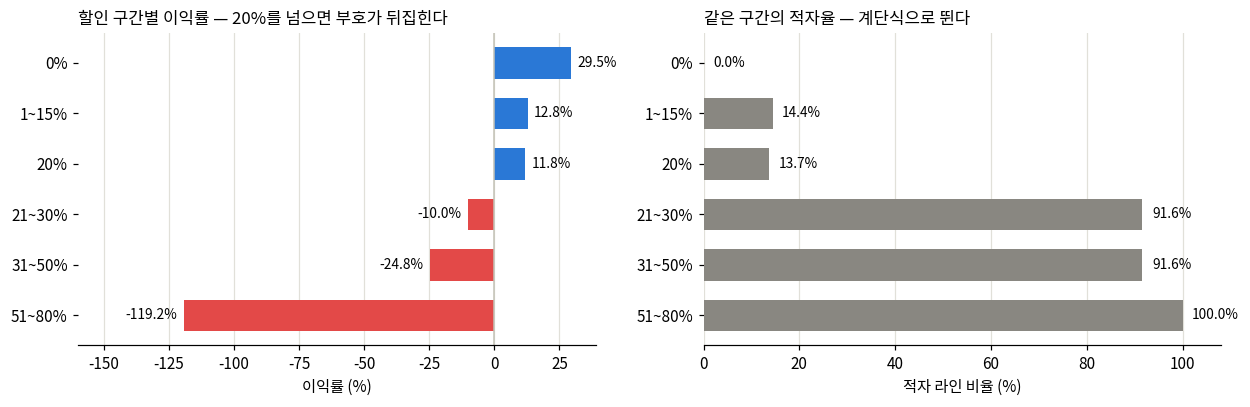

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))

# 왼쪽 — 이익률 (부호가 뒤집히므로 0 기준선 + 발산 색)
colors = [RED if v < 0 else BLUE for v in band["이익률(%)"]]
ax[0].barh(band["할인 구간"], band["이익률(%)"], color=colors, height=.62)
ax[0].axvline(0, color="#c3c2b7", lw=1)
ax[0].invert_yaxis()
ax[0].set_xlabel("이익률 (%)")
ax[0].set_title("할인 구간별 이익률 — 20%를 넘으면 부호가 뒤집힌다", loc="left", fontsize=11)
# 라벨이 축 눈금과 겹치지 않도록 왼쪽 여유를 넉넉히 준다
ax[0].set_xlim(band["이익률(%)"].min() * 1.34, band["이익률(%)"].max() * 1.32)
for y, v in enumerate(band["이익률(%)"]):
    ax[0].text(v + (2.5 if v >= 0 else -2.5), y, f"{v:.1f}%",
               va="center", ha="left" if v >= 0 else "right", fontsize=9)

# 오른쪽 — 적자율
ax[1].barh(band["할인 구간"], band["적자율(%)"], color=GRAY, height=.62)
ax[1].invert_yaxis()
ax[1].set_xlim(0, 108)
ax[1].set_xlabel("적자 라인 비율 (%)")
ax[1].set_title("같은 구간의 적자율 — 계단식으로 뛴다", loc="left", fontsize=11)
for y, v in enumerate(band["적자율(%)"]):
    ax[1].text(v + 2, y, f"{v:.1f}%", va="center", fontsize=9)

for a in ax:
    a.grid(axis="x", color=GRID, lw=.8); a.set_axisbelow(True)
    for s in ("top","right","left"): a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [25]:
z = us[us["Discount"] == 0]
h = us[us["Discount"] > 0.30]
risk = us[us["Discount"] > 0.20]

print(f"""할인 0%            {len(z):>5,}건 | 이익률 {z['Profit'].sum()/z['Sales'].sum()*100:>6.1f}% | 적자 {int((z['Profit']<0).sum()):>4}건
할인 30% 초과      {len(h):>5,}건 | 이익률 {h['Profit'].sum()/h['Sales'].sum()*100:>6.1f}% | 적자율 {(h['Profit']<0).mean()*100:.1f}%

손실 위험 구간 (할인 20% 초과)
  라인수      {len(risk):,}건 ({len(risk)/len(us)*100:.1f}%)
  매출        ${risk['Sales'].sum():,.0f} (전체의 {risk['Sales'].sum()/S*100:.1f}%)
  이익        ${risk['Profit'].sum():,.0f}
  → 이 구간 손실을 0으로 만들면 되찾는 이익 = ${-risk['Profit'].sum():,.0f}
    (현재 이익 ${P:,.0f} 의 {-risk['Profit'].sum()/P*100:.0f}%)

적자 전체
  적자 라인 {int((us['Profit']<0).sum()):,}건, 손실 합계 ${us.loc[us['Profit']<0,'Profit'].sum():,.0f}
  흑자 라인 이익 합계 ${us.loc[us['Profit']>0,'Profit'].sum():,.0f}
  → 적자가 흑자 이익의 {-us.loc[us['Profit']<0,'Profit'].sum()/us.loc[us['Profit']>0,'Profit'].sum()*100:.1f}%를 상쇄""")

할인 0%            4,798건 | 이익률   29.5% | 적자    0건
할인 30% 초과      1,166건 | 이익률  -48.2% | 적자율 97.8%

손실 위험 구간 (할인 20% 초과)
  라인수      1,393건 (13.9%)
  매출        $362,770 (전체의 15.8%)
  이익        $-135,376
  → 이 구간 손실을 0으로 만들면 되찾는 이익 = $135,376
    (현재 이익 $286,397 의 47%)

적자 전체
  적자 라인 1,871건, 손실 합계 $-156,131
  흑자 라인 이익 합계 $442,528
  → 적자가 흑자 이익의 35.3%를 상쇄


### 발견 A — 상관계수 −0.22가 약해 보였던 이유

**관계가 선형이 아니라 계단식이기 때문이다.**

| 할인 구간 | 이익률 | 적자율 |
|---|---|---|
| 0% | **+29.5%** | **0.0%** |
| 20% | +11.8% | 13.7% |
| **21~30%** | **−10.0%** | **91.6%** ← 여기서 뒤집힌다 |
| 51~80% | −119.2% | 100.0% |

**할인 0%에서는 적자 주문이 단 한 건도 없다.** 4,798건 전부 흑자다.
반대로 할인 51% 이상 856건은 **전부 적자**다.

임계점은 **할인 20%**다. 20%까지는 적자율 13.7%인데 20%를 넘으면 91.6%로 뛴다.
완만한 증가가 아니라 계단이므로, **정책 기준선을 20%로 두는 것이 데이터에서 나온다.**

> **회수 가능 이익 = $135,376** (현재 이익의 47%)
>
> ⚠️ 단, 이 값은 **상한값**이다. 할인을 줄이면 그 매출의 일부는 이탈하므로
> 실제 회수액은 이보다 작다. 매출 이탈률을 추정할 근거가 이 데이터에 없어
> 대시보드에서도 "상한"으로 표기했다.

## 10. 핵심 분석 B — 어떤 상품에서 새는가

In [26]:
sub = us.groupby("Sub-Category").agg(
    라인수=("Row ID","size"), 매출=("Sales","sum"), 이익=("Profit","sum"),
    평균할인=("Discount","mean"),
)
sub["이익률(%)"] = (sub["이익"] / sub["매출"] * 100).round(2)
sub["평균할인(%)"] = (sub["평균할인"] * 100).round(1)
sub["적자율(%)"] = us.groupby("Sub-Category")["Profit"].apply(lambda s: (s < 0).mean() * 100).round(1)
sub = sub.drop(columns="평균할인").sort_values("이익")
sub

,라인수,매출,이익,이익률(%),평균할인(%),적자율(%)
Sub-Category,,,,,,
Tables,319,"206,965.53","-17,725.48",-8.56,26.10,63.60
Bookcases,228,"114,880.00","-3,472.56",-3.02,21.10,47.80
Supplies,190,"46,673.54","-1,189.10",-2.55,7.70,17.40
Fasteners,217,"3,024.28",949.52,31.40,8.20,5.50
Machines,115,"189,238.63","3,384.76",1.79,30.60,38.30
Labels,364,"12,486.31","5,546.25",44.42,6.90,0.00
Art,796,"27,118.79","6,527.79",24.07,7.50,0.00
Envelopes,254,"16,476.40","6,964.18",42.27,8.00,0.00
Furnishings,957,"91,705.16","13,059.14",14.24,13.80,17.50


In [27]:
# 하위카테고리 × 할인구간 — 같은 상품이 할인에 따라 뒤집히는지 확인
us["할인구간"] = np.where(d100.loc[us.index] == 0, "0%",
                  np.where(d100.loc[us.index] <= 20, "1~20%", "20% 초과"))
ORDER = ["0%", "1~20%", "20% 초과"]

pv_profit = us.pivot_table(index="Sub-Category", columns="할인구간",
                           values="Profit", aggfunc="sum").reindex(columns=ORDER)
pv_sales  = us.pivot_table(index="Sub-Category", columns="할인구간",
                           values="Sales", aggfunc="sum").reindex(columns=ORDER)
pv_margin = (pv_profit / pv_sales * 100)

order_idx = pv_profit.sum(axis=1).sort_values().index
print("이익 ($) — 행은 통년 이익 낮은 순")
print(pv_profit.loc[order_idx].round(0).to_string())

이익 ($) — 행은 통년 이익 낮은 순
할인구간                0%     1~20%     20% 초과
Sub-Category                               
Tables       13,276.00   -304.00 -30,698.00
Bookcases     6,076.00  1,549.00 -11,098.00
Supplies      1,718.00 -2,907.00        NaN
Fasteners       652.00    297.00        NaN
Machines     27,138.00  5,802.00 -29,555.00
Labels        4,422.00  1,124.00        NaN
Art           5,381.00  1,147.00        NaN
Envelopes     4,977.00  1,987.00        NaN
Furnishings  16,848.00  2,156.00  -5,945.00
Appliances   23,184.00  3,584.00  -8,630.00
Storage      25,528.00 -4,249.00        NaN
Chairs       21,933.00 11,394.00  -6,737.00
Binders      39,314.00 29,418.00 -38,510.00
Paper        25,329.00  8,724.00        NaN
Accessories  35,289.00  6,647.00        NaN
Phones       34,365.00 16,536.00  -6,386.00
Copiers      35,556.00 17,879.00   2,183.00


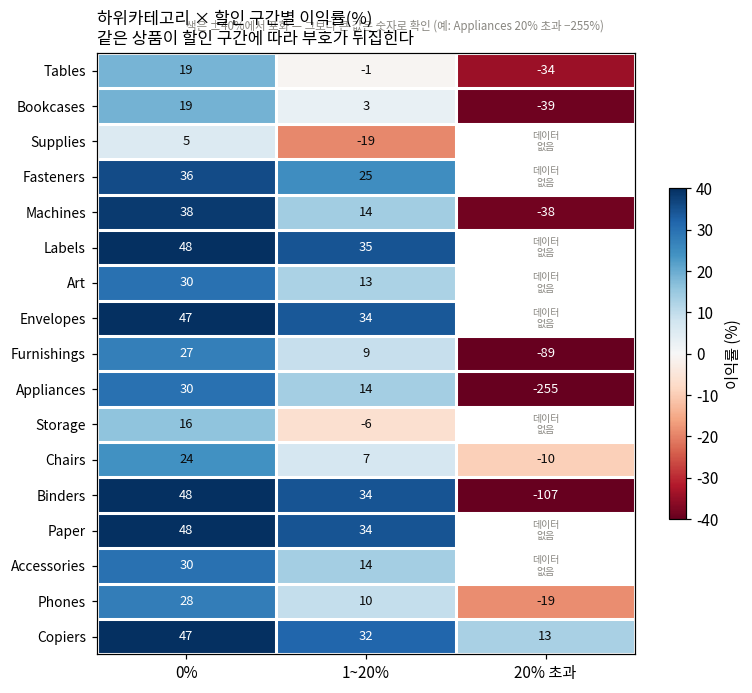

In [28]:
m = pv_margin.loc[order_idx]
fig, ax = plt.subplots(figsize=(7.2, 6.4))
im = ax.imshow(m.values, cmap="RdBu", vmin=-40, vmax=40, aspect="auto")

ax.set_xticks(range(len(ORDER)), ORDER)
ax.set_yticks(range(len(m)), m.index, fontsize=9)
ax.set_title("하위카테고리 × 할인 구간별 이익률(%)\n같은 상품이 할인 구간에 따라 부호가 뒤집힌다",
             loc="left", fontsize=11)
ax.text(0, -1.15, "색은 ±40%에서 포화 — 그보다 큰 값은 숫자로 확인 (예: Appliances 20% 초과 −255%)",
        fontsize=7.5, color=GRAY)

for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "데이터\n없음", ha="center", va="center", fontsize=6.5, color=GRAY)
        else:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5,
                    color="white" if abs(v) > 26 else "#0b0b0b")
ax.set_xticks(np.arange(-.5, len(ORDER), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(m), 1), minor=True)
ax.grid(which="minor", color="white", lw=2)
ax.tick_params(which="minor", length=0)
fig.colorbar(im, ax=ax, shrink=.55, label="이익률 (%)")
plt.tight_layout(); plt.show()

### 발견 B — 상품이 문제가 아니라 할인이 문제다

**통년 적자 하위카테고리 3개** — Tables (−$17,725 · 이익률 −8.6%), Bookcases (−$3,473), Supplies (−$1,189)

하지만 히트맵을 보면 더 중요한 게 보인다. **할인 0% 열은 거의 전부 파랑(흑자)이다.**
흑자 상품조차 할인 20%를 넘는 구간에서는 빨강으로 뒤집힌다.

| 하위카테고리 | 할인 0% 이익 | 할인 20% 초과 이익 |
|---|---|---|
| Binders | **+$39,314** | **−$38,510** |
| Machines | +$27,138 | −$29,555 |
| Tables | +$13,276 | −$30,698 |

Binders는 통년으로는 흑자 3위 상품인데, 고할인 구간만 보면 최대 손실원이다.
즉 **"Binders를 팔지 말라"가 아니라 "Binders를 20% 넘게 할인하지 말라"** 가 옳은 결론이다.

이게 이 데이터에서 나온 가장 실행 가능한 판단이고, 대시보드 ③번 차트의 근거가 되었다.

## 11. 핵심 분석 C — 어느 지역에서 새는가

In [29]:
reg = us.groupby("Region").agg(
    매출=("Sales","sum"), 이익=("Profit","sum"),
    평균할인=("Discount","mean"), 라인수=("Row ID","size"),
)
reg["이익률(%)"] = (reg["이익"] / reg["매출"] * 100).round(2)
reg["평균할인(%)"] = (reg["평균할인"] * 100).round(1)
reg["적자율(%)"] = us.groupby("Region")["Profit"].apply(lambda s: (s < 0).mean() * 100).round(1)
reg = reg.drop(columns="평균할인")

# People 시트를 붙여 책임자를 명시한다
reg = reg.join(people.set_index("Region")["Regional Manager"])
reg.sort_values("이익률(%)")

,매출,이익,라인수,이익률(%),평균할인(%),적자율(%),Regional Manager
Region,,,,,,,
Central,"501,239.89","39,706.36",2323,7.92,24.00,31.90,Roxanne Rodriguez
South,"391,721.91","46,749.43",1620,11.93,14.70,16.00,Fred Suzuki
East,"678,781.24","91,522.78",2848,13.48,14.50,19.40,Chuck Magee
West,"725,457.82","108,418.45",3203,14.94,10.90,9.90,Sadie Pawthorne


In [30]:
print("Region × Category 이익률(%) — 유일한 마이너스 칸을 찾는다")
rc = (us.pivot_table(index="Region", columns="Category", values="Profit", aggfunc="sum") /
      us.pivot_table(index="Region", columns="Category", values="Sales",  aggfunc="sum") * 100)
print(rc.round(2).to_string())

Region × Category 이익률(%) — 유일한 마이너스 칸을 찾는다
Category  Furniture  Office Supplies  Technology
Region                                          
Central       -1.75             5.32       19.77
East           1.46            19.96       17.91
South          5.77            15.91       13.44
West           4.55            23.82       17.58


In [31]:
st = us.groupby("State/Province").agg(
    매출=("Sales","sum"), 이익=("Profit","sum"),
    평균할인=("Discount","mean"), 라인수=("Row ID","size"),
)
st["이익률(%)"] = (st["이익"] / st["매출"] * 100).round(2)
st["평균할인(%)"] = (st["평균할인"] * 100).round(1)

loss_states = st[st["이익"] < 0].sort_values("이익")
print(f"적자 주 {len(loss_states)}개 / 전체 {len(st)}개, 합산 손실 ${loss_states['이익'].sum():,.0f}\n")
print(loss_states[["매출","이익","이익률(%)","평균할인(%)","라인수"]].to_string())
print("\n흑자 상위 5개 — 평균 할인율을 비교해 보라")
print(st.nlargest(5, "이익")[["매출","이익","이익률(%)","평균할인(%)"]].to_string())

적자 주 10개 / 전체 49개, 합산 손실 $-98,247

                       매출         이익  이익률(%)  평균할인(%)  라인수
State/Province                                            
Texas          170,188.05 -25,729.36  -15.12    37.00  985
Ohio            78,258.14 -16,971.38  -21.69    32.50  469
Pennsylvania   116,511.91 -15,559.96  -13.35    32.90  587
Illinois        80,166.10 -12,607.89  -15.73    39.00  492
North Carolina  55,603.16  -7,490.91  -13.47    28.40  249
Colorado        32,108.12  -6,527.86  -20.33    31.60  182
Tennessee       30,661.87  -5,341.69  -17.42    29.10  183
Arizona         35,282.00  -3,427.92   -9.72    30.40  224
Florida         89,473.71  -3,399.30   -3.80    29.90  383
Oregon          17,431.15  -1,190.47   -6.83    28.90  124

흑자 상위 5개 — 평균 할인율을 비교해 보라
                       매출        이익  이익률(%)  평균할인(%)
State/Province                                      
California     457,687.63 76,381.39   16.69     7.30
New York       310,876.27 74,038.55   23.82     5.50
Washington     138

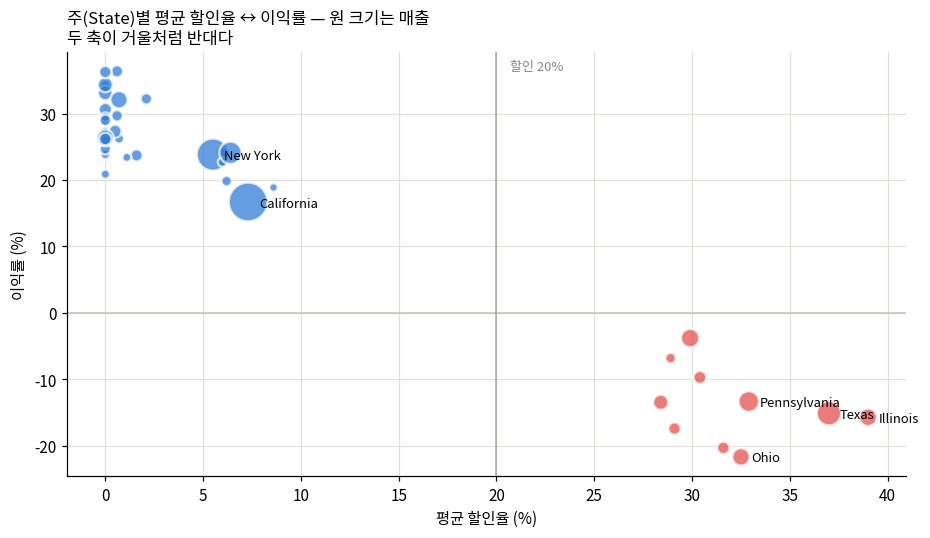

평균 할인율과 이익률의 상관계수 (주 단위): -0.971


In [32]:
sub_st = st[st["라인수"] >= 20]           # 표본 20라인 미만은 제외
fig, ax = plt.subplots(figsize=(8.6, 5))
ax.scatter(sub_st["평균할인(%)"], sub_st["이익률(%)"],
           s=sub_st["매출"] / sub_st["매출"].max() * 620 + 24,
           c=[RED if v < 0 else BLUE for v in sub_st["이익"]],
           alpha=.72, edgecolors="white", linewidths=1.6)

ax.axhline(0, color="#c3c2b7", lw=1)
ax.axvline(20, color=GRAY, lw=1, alpha=.7)
ax.text(20.7, ax.get_ylim()[1] * .93, "할인 20%", fontsize=8.5, color=GRAY)
ax.set_xlabel("평균 할인율 (%)"); ax.set_ylabel("이익률 (%)")
ax.set_title("주(State)별 평균 할인율 ↔ 이익률 — 원 크기는 매출\n두 축이 거울처럼 반대다",
             loc="left", fontsize=11)

for name in ["Texas","Ohio","Pennsylvania","Illinois","California","New York"]:
    if name in sub_st.index:
        r = sub_st.loc[name]
        ax.annotate(name, (r["평균할인(%)"], r["이익률(%)"]),
                    xytext=(7, -3), textcoords="offset points", fontsize=8.5)

ax.grid(color=GRID, lw=.8); ax.set_axisbelow(True)
for s in ("top","right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print(f"평균 할인율과 이익률의 상관계수 (주 단위): {sub_st['평균할인(%)'].corr(sub_st['이익률(%)']):.3f}")

### 발견 C — 지역 성과 차이가 아니라 할인 관행 차이다

| | 평균 할인 | 이익률 |
|---|---|---|
| **적자 주** (Texas, Ohio, Pennsylvania, Illinois 등 10개) | 28 ~ 39% | −3.8% ~ −21.7% |
| **흑자 상위** (California, New York, Washington, Michigan) | 0 ~ 7% | +16.7% ~ +32.1% |

주 단위로 보면 **평균 할인율과 이익률의 상관이 −0.971**다.
9절의 라인 단위 상관 −0.22와 비교하면, 집계 수준을 올리자 관계가 압도적으로 선명해졌다.
개별 주문의 잡음이 걷히고 **정책 차이**가 드러난 것이다.

⚠️ 다만 이 −0.971은 **주 47개를 하나의 점으로 압축한 값**이므로 라인 단위 상관보다 과장돼 보인다
(집계 단위를 올리면 상관이 부풀려지는 것은 일반적인 현상이다).
"할인율이 높은 주가 이익률이 낮다"는 방향은 신뢰할 수 있지만,
−0.971이라는 크기 자체를 개별 주문 수준의 인과 강도로 읽으면 안 된다.

지역 단위에서도 같은 패턴이다 — Central은 평균 할인 24%로 가장 높고 이익률 7.9%로 가장 낮다.
**Region × Category에서 유일한 마이너스 칸이 Central × Furniture (−1.75%)** 다.

`People` 시트를 붙여 각 권역 책임자를 명시했다. 다만 **개인의 성과 문제로 해석하지 않는다** —
할인 승인 권한과 프로세스의 문제일 가능성이 높고, 이 데이터로는 구분할 수 없다.

## 12. 보조 분석 — 대시보드에 넣지 않은 것

EDA에서 확인했지만 대시보드 화면에는 **의도적으로 넣지 않은** 항목들이다.

Part 4 Ch 6의 첫 번째 안티패턴이 **"만능 대시보드"** 다.
지표를 더 넣으면 우선순위가 흐려진다. 그래서 "봤지만 뺐다"를 기록으로 남긴다.

In [33]:
# ① 고객 집중도와 적자 고객
cust = us.groupby("Customer ID").agg(매출=("Sales","sum"), 이익=("Profit","sum"))
top10 = cust.nlargest(int(len(cust) * .1), "매출")
print(f"""고객 분석
  전체 고객                 {len(cust):,}명
  상위 10%({len(top10)}명) 매출 비중  {top10['매출'].sum()/cust['매출'].sum()*100:.1f}%
  적자 고객                 {int((cust['이익']<0).sum()):,}명 ({(cust['이익']<0).mean()*100:.1f}%)
  적자 고객 손실 합계        ${cust.loc[cust['이익']<0,'이익'].sum():,.0f}""")

고객 분석
  전체 고객                 793명
  상위 10%(79명) 매출 비중  30.6%
  적자 고객                 155명 (19.5%)
  적자 고객 손실 합계        $-71,224


In [34]:
# ② 반품 — 차원별
print("반품률 (주문 기준, %)")
for c in ["Category","Segment","Ship Mode"]:
    out = []
    for k, g in us.groupby(c):
        out.append((k, round(g.loc[g["반품여부"],"Order ID"].nunique() / g["Order ID"].nunique() * 100, 2)))
    print(f"\n[{c}]")
    for k, v in sorted(out, key=lambda x: -x[1]):
        print(f"  {k:<18} {v:>6.2f}")

반품률 (주문 기준, %)

[Category]
  Technology           7.97
  Furniture            7.71
  Office Supplies      6.25

[Segment]
  Corporate            6.14
  Consumer             5.96
  Home Office          5.39

[Ship Mode]
  Same Day             7.20
  First Class          6.86
  Second Class         5.71
  Standard Class       5.61


In [35]:
# ③ 배송 소요일과 이익의 관계 — 관계가 있는지만 확인
print("배송 모드별 이익률")
sm = us.groupby("Ship Mode").agg(매출=("Sales","sum"), 이익=("Profit","sum"),
                                 평균할인=("Discount","mean"), 라인수=("Row ID","size"))
sm["이익률(%)"] = (sm["이익"] / sm["매출"] * 100).round(2)
sm["평균할인(%)"] = (sm["평균할인"] * 100).round(1)
print(sm.drop(columns="평균할인").to_string())
print(f"\n배송소요일 ↔ 이익 상관: {us['배송소요일'].corr(us['Profit']):.3f}  ← 사실상 무관")

배송 모드별 이익률
                         매출         이익   라인수  이익률(%)  평균할인(%)
Ship Mode                                                    
First Class      351,428.42  48,969.84  1538   13.93    16.50
Same Day         128,363.12  15,891.76   543   12.38    15.20
Second Class     459,193.57  57,446.64  1945   12.51    13.90
Standard Class 1,358,215.74 164,088.79  5968   12.08    16.00

배송소요일 ↔ 이익 상관: -0.005  ← 사실상 무관


### 뺀 이유

| 발견 | 수치 | 뺀 이유 |
|---|---|---|
| **적자 고객 155명** (19.8%) | 손실 $71,224 | 고객 축을 넣으면 화면이 **두 개 주제**가 된다. 할인 정책과 고객 관리는 다른 결정이고 다른 담당자다 → 별도 화면으로 분리하는 게 맞다 |
| **West 반품률 11.73%** | 다른 지역 2.9~3.3% | 원인 특정 불가 (7절 플래그 1). 근거가 불확실한 숫자는 잘못된 행동을 유발한다 |
| 반품률 × 카테고리 · 세그먼트 | 5.3 ~ 7.9% 범위 | 차이가 작아 **행동으로 연결되지 않는다.** Part 4 Ch 3의 결정 테스트 불합격 |
| 배송 소요일 | 이익과 상관 −0.01 | 관계가 없다. 넣을 이유가 없다 |
| 고객 집중도 (상위 10%가 매출 31%) | — | 흥미롭지만 이 화면이 답할 질문이 아니다 |

**남긴 것은 5개 지표뿐이다** — 매출 · 이익률 · 손실 위험 매출 · 회수 가능 이익 · 조치 우선순위.
전부 "이 숫자가 바뀌면 누가 무엇을 다르게 하는가"에 답이 있다.

## 13. 지표 정의

대시보드에서 쓰는 지표의 계산식을 확정한다. Part 4 Ch 3 — *정의 · 분모 · 기간 · 출처를 명확히*.

| 지표 | 계산식 | 주의 |
|---|---|---|
| **이익률** | `Profit 합계 ÷ Sales 합계 × 100` | 행별 이익률의 **평균이 아니다**. 왜도 7.6이라 평균은 소액 주문에 끌려간다 |
| **적자율** | `Profit < 0 인 라인 수 ÷ 전체 라인 수 × 100` | 분모는 **주문 라인**이지 주문이 아니다 |
| **평균 할인율** | `Discount 평균 × 100` | 라인 단위 단순평균. 매출 가중이 아니다 |
| **손실 위험 매출** | `Discount > 20% 인 라인의 Sales 합계` | 20% 기준은 적자율이 계단식으로 뛰는 지점 (9절) |
| **회수 가능 이익** | `−(Discount > 20% 구간의 Profit 합계)` | **상한값.** 할인 축소로 인한 매출 이탈 미반영 |
| **반품률** | `반품된 Order ID 수 ÷ 전체 Order ID 수` | 라인이 아니라 **주문** 기준 (그레인 주의) |
| **목표 이익률 15%** | 데이터 외부 가정 | 최고 실적 지역 West 14.9% 기준 — 달성 가능함이 입증된 수치 |

## 14. 결론 — 대시보드 설계로

### EDA가 답한 것

1. **데이터는 믿을 수 있다** — 결측 0, 논리 오류 0. 플래그 5개는 기록하고 그 중 1개는 범위 축소로 대응했다
2. **가장 강한 신호는 할인율이다** — 매출이 아니라 할인이 이익의 부호를 결정한다
3. **행동으로 연결되는 지표 5개를 남기고 나머지를 뺐다**

### 대시보드 설계 결정 (Part 4 Ch 1의 순서대로)

| 단계 | 결정 | 근거 |
|---|---|---|
| **유형** | 분석형 | 실시간 지표·임계값 없음 → 운영형 불가. 지표 수와 드릴다운 깊이 → 전략형도 아님 |
| **대상** | 영업 총괄 · 상품 담당자 · 지역 매니저 4명 | `People` 시트의 권역 책임자 |
| **지표** | 회수 가능 이익을 핵심으로 + 보조 3개 | 9절 |
| **질문** | Q1 어디서 뒤집히는가 / Q2 누가 원인인가 / Q3 무엇부터 손대는가 | 9 · 10 · 11절이 각각 대응 |
| **차트** | 발산형 막대 · 산점도 · 히트맵 · 선 · 판정 표 | 이 노트북의 그림들이 그대로 대시보드가 되었다 |

### 다음 단계

이 EDA를 근거로 대시보드를 제작했다 → `superstore_discount_dashboard.html`

---

## 부록 — 재현 방법

```
프로젝트 폴더/
├─ superstore_eda.ipynb              ← 이 노트북
├─ sample_-_superstore.xls           ← 원본 데이터 (같은 폴더에 두면 자동 인식)
└─ superstore_discount_dashboard.html
```

필요 패키지: `pandas`, `numpy`, `matplotlib`, `xlrd`(구형 `.xls` 읽기용)

```bash
pip install pandas numpy matplotlib xlrd
```

노트북을 위에서 아래로 순서대로 실행하면 이 문서의 모든 수치가 재현된다.
난수를 쓰지 않으므로 결과는 항상 동일하다.